# Visit-level baseline - for full metrics
Visit-level readmission model reporting accuracy, precision, recall, F1 and AUROC - the metric suite Roantree asked for it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve)
from xgboost import XGBClassifier

DATA_DIR = "/Users/robert/Desktop/hospital-re-admission/data/processed"
RESULTS_DIR = "/Users/robert/Desktop/hospital-re-admission/notebooks/16_visit_baseline_metrics"
SEED = 42

## Load visit-level data
One row per admission (the original approach). Targets already present.
Split is the original visit-level train/test files.

In [2]:
train = pd.read_csv(f"{DATA_DIR}/train_data_clean.csv")
test = pd.read_csv(f"{DATA_DIR}/test_data_clean.csv")

cat_cols = ["gender", "race", "marital_status", "language", "insurance",
            "admission_type", "admission_location", "discharge_location"]
targets = ["readmitted_30d", "readmitted_60d", "readmitted_90d"]
drop_cols = ["subject_id", "hadm_id", "admittime", "dischtime"] + targets
features = [c for c in train.columns if c not in drop_cols]

# Encode categoricals on train, map unseen test values to -1.
Xtr, Xte = train[features].copy(), test[features].copy()
for c in cat_cols:
    mapping = {v: i for i, v in enumerate(sorted(Xtr[c].astype(str).unique()))}
    Xtr[c] = Xtr[c].astype(str).map(mapping).fillna(-1).astype(int)
    Xte[c] = Xte[c].astype(str).map(mapping).fillna(-1).astype(int)
print(f"train {len(Xtr):,}  test {len(Xte):,}  features {len(features)}")

train 324,824  test 81,207  features 46


## Score each window
Same recipe as the patient-level models: 5-fold CV, F1-best threshold from CV,
retrain on all train, evaluate on test. All five metrics.

In [3]:
def new_model():
    return XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.05, subsample=0.8,
                         colsample_bytree=0.8, reg_lambda=2, reg_alpha=0.1, min_child_weight=5,
                         eval_metric="logloss", tree_method="hist",
                         random_state=SEED, n_jobs=4)

def evaluate(target):
    ytr, yte = train[target].values, test[target].values
    skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
    oof = np.zeros(len(ytr)); fold_auc = []
    for a, b in skf.split(Xtr, ytr):
        spw = (ytr[a] == 0).sum() / (ytr[a] == 1).sum()   # Table III: training-fold neg:pos ratio
        m = new_model(); m.set_params(scale_pos_weight=spw)
        m.fit(Xtr.iloc[a], ytr[a])
        oof[b] = m.predict_proba(Xtr.iloc[b])[:, 1]
        fold_auc.append(roc_auc_score(ytr[b], oof[b]))
    thresholds = np.linspace(0.1, 0.9, 33)
    thr = max(thresholds, key=lambda t: f1_score(ytr, (oof >= t).astype(int), zero_division=0))
    spw_full = (ytr == 0).sum() / (ytr == 1).sum()
    m = new_model(); m.set_params(scale_pos_weight=spw_full)
    m.fit(Xtr, ytr)
    proba = m.predict_proba(Xte)[:, 1]; pred = (proba >= thr).astype(int)
    if target == "readmitted_30d":
        np.save("xgb_canonical_30d_test_proba.npy", proba)   # for Figure 2 later
    return {"target": target,
            "cv_auroc": round(np.mean(fold_auc), 3), "cv_auroc_std": round(np.std(fold_auc), 3),
            "threshold": round(thr, 2),
            "accuracy": round(accuracy_score(yte, pred), 3),
            "precision": round(precision_score(yte, pred, zero_division=0), 3),
            "recall": round(recall_score(yte, pred, zero_division=0), 3),
            "f1": round(f1_score(yte, pred, zero_division=0), 3),
            "test_auroc": round(roc_auc_score(yte, proba), 3)}, (yte, proba)

results, roc_data = [], {}
for t in targets:
    r, rc = evaluate(t); results.append(r); roc_data[t] = rc
summary = pd.DataFrame(results)
print(summary.to_string(index=False))
summary.to_csv(f"{RESULTS_DIR}/visit_baseline_scores.csv", index=False)

        target  cv_auroc  cv_auroc_std  threshold  accuracy  precision  recall    f1  test_auroc
readmitted_30d     0.725         0.003       0.52     0.686      0.309   0.612 0.411       0.720
readmitted_60d     0.738         0.001       0.50     0.664      0.393   0.682 0.499       0.734
readmitted_90d     0.746         0.002       0.48     0.653      0.436   0.730 0.546       0.743


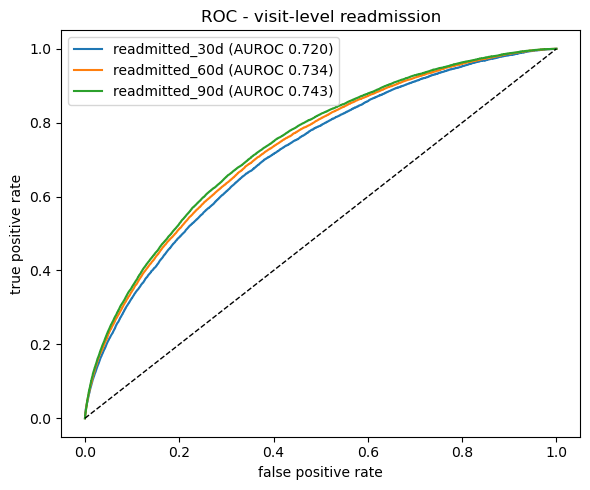

In [4]:
# Graph: ROC for the three visit-level windows.
import os
os.makedirs(RESULTS_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 5))
for t, (yte, proba) in roc_data.items():
    fpr, tpr, _ = roc_curve(yte, proba)
    ax.plot(fpr, tpr, label=f"{t} (AUROC {roc_auc_score(yte, proba):.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title("ROC - visit-level readmission"); ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/visit_baseline_roc.png", dpi=150)
plt.savefig("visit_baseline_roc.png", dpi=150)
plt.show()